In [ ]:
# Run this first
!pip install scikit-learn tensorflow matplotlib seaborn numpy pandas scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
# ============================================
# STEP 2: UPLOAD YOUR DATASET MANUALLY
# ============================================

print("="*70)
print("STEP 1: UPLOAD DAPHNET FREEZING OF GAIT DATASET")
print("="*70)
print("\nPlease upload the Daphnet dataset file (ZIP or individual .txt files)")
print("You can download it from: https://archive.ics.uci.edu/static/public/245/daphnet+freezing+of+gait.zip")
print("\n" + "-"*50)

# Upload file
uploaded = files.upload()

# Get uploaded filename
file_names = list(uploaded.keys())
print(f"\n Uploaded {len(file_names)} file(s): {file_names}")

# Check if it's a ZIP file
if file_names[0].endswith('.zip'):
    print("\n Extracting ZIP file...")
    with zipfile.ZipFile(file_names[0], 'r') as zip_ref:
        zip_ref.extractall('/content/daphnet_data')
    print(" Extraction complete!")
    data_path = '/content/daphnet_data'
else:
    # Create directory for multiple .txt files
    os.makedirs('/content/daphnet_data', exist_ok=True)
    for fname in file_names:
        os.rename(fname, f'/content/daphnet_data/{fname}')
    data_path = '/content/daphnet_data'
    print(f"\n Saved {len(file_names)} files to {data_path}")

# List available files
print("\n Available files:")
for f in os.listdir(data_path):
    if f.endswith('.txt'):
        print(f"   - {f}")

STEP 1: UPLOAD DAPHNET FREEZING OF GAIT DATASET

Please upload the Daphnet dataset file (ZIP or individual .txt files)
You can download it from: https://archive.ics.uci.edu/static/public/245/daphnet+freezing+of+gait.zip

--------------------------------------------------


Saving S02R02.txt to S02R02.txt

 Uploaded 1 file(s): ['S02R02.txt']

 Saved 1 files to /content/daphnet_data

 Available files:
   - S01R01.txt
   - S02R02.txt


In [ ]:
# ============================================
# STEP 3: LOAD AND PARSE DATA FILES
# ============================================

print("\n" + "="*70)
print("STEP 2: LOADING DATA FILES")
print("="*70)

def load_daphnet_file(filepath):
    """
    Load a single Daphnet data file
    Format: time, ankle_x, ankle_y, ankle_z, thigh_x, thigh_y, thigh_z,
            trunk_x, trunk_y, trunk_z, annotation
    """
    # Read file (space-separated, no header)
    df = pd.read_csv(filepath, header=None, sep='\s+')

    # Assign column names
    df.columns = ['time_ms',
                  'ankle_x', 'ankle_y', 'ankle_z',
                  'thigh_x', 'thigh_y', 'thigh_z',
                  'trunk_x', 'trunk_y', 'trunk_z',
                  'annotation']

    # Convert time to seconds
    df['time_s'] = df['time_ms'] / 1000

    return df

# Load all .txt files
all_data = []
file_list = [f for f in os.listdir(data_path) if f.endswith('.txt')]

for file in file_list:
    filepath = os.path.join(data_path, file)
    df = load_daphnet_file(filepath)
    all_data.append(df)
    print(f" Loaded {file}: {len(df)} samples")

print(f"\n Total files loaded: {len(all_data)}")
print(f"   Total samples: {sum(len(df) for df in all_data)}")


STEP 2: LOADING DATA FILES
 Loaded S01R01.txt: 151987 samples
 Loaded S02R02.txt: 89645 samples

 Total files loaded: 2
   Total samples: 241632



STEP 3: DATA EXPLORATION

 First file preview:
   time_ms  ankle_x  ankle_y  ankle_z  thigh_x  thigh_y  thigh_z  trunk_x  \
0       15       70       39     -970        0        0        0        0   
1       31       70       39     -970        0        0        0        0   
2       46       60       49     -960        0        0        0        0   
3       62       60       49     -960        0        0        0        0   
4       78       50       39     -960        0        0        0        0   
5       93       50       39     -960        0        0        0        0   
6      109       60       39     -990        0        0        0        0   
7      125       70       29     -980        0        0        0        0   
8      140       70       29     -980        0        0        0        0   
9      156       70       29     -970        0        0        0        0   

   trunk_y  trunk_z  annotation  time_s  
0        0        0           0   0.015  
1        0        0 

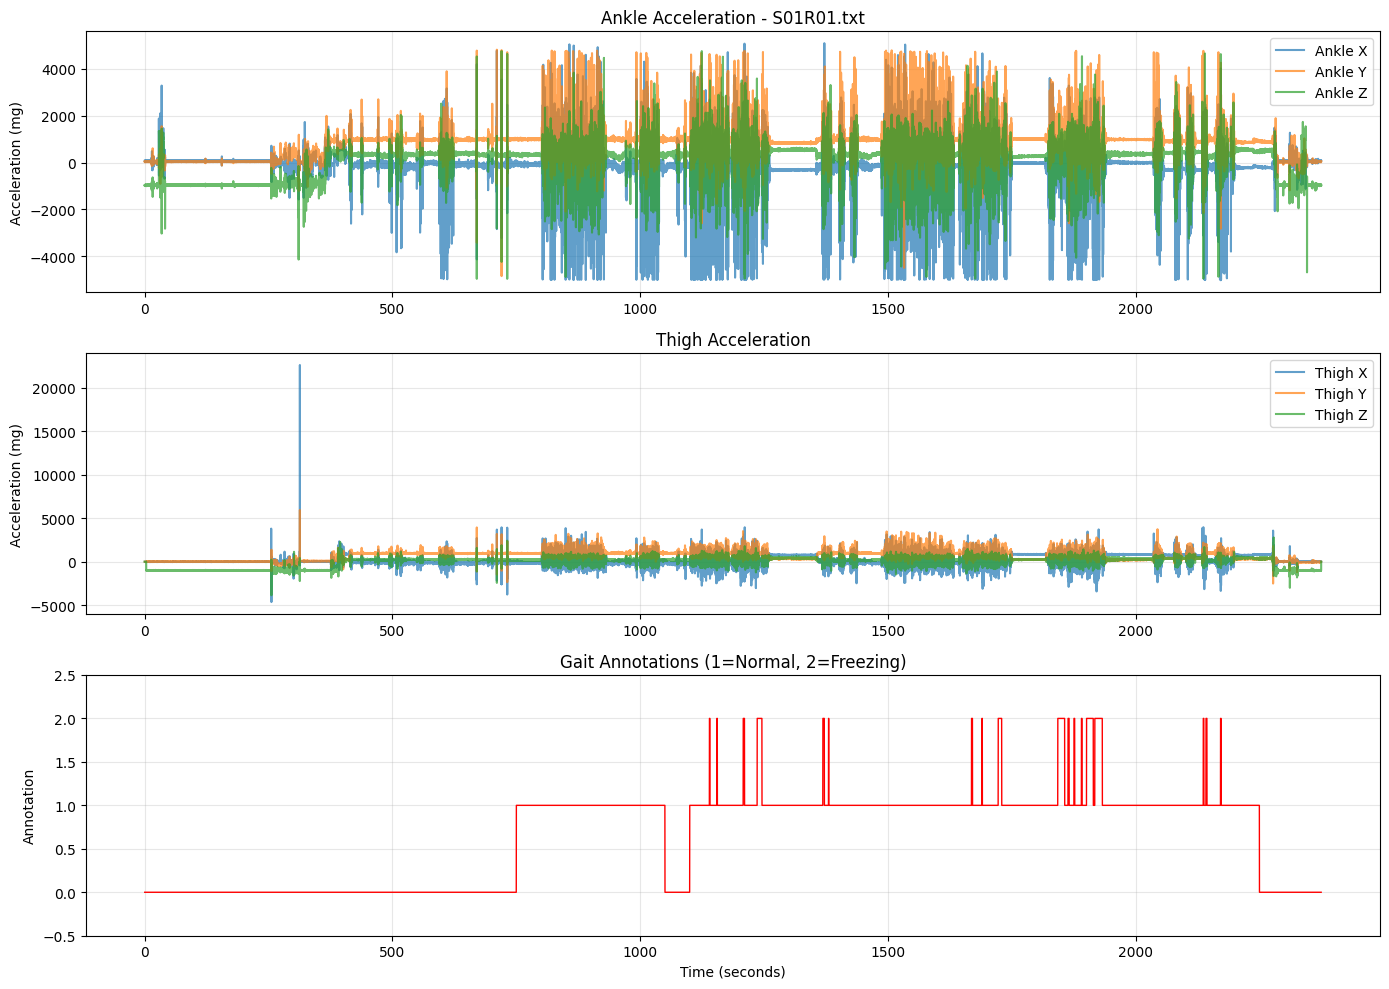


 Data exploration complete! Figure saved as 'data_exploration.png'


In [ ]:
# ============================================
# STEP 4: EXPLORE THE DATA
# ============================================

print("\n" + "="*70)
print("STEP 3: DATA EXPLORATION")
print("="*70)

# Display first few rows of first file
print("\n First file preview:")
print(all_data[0].head(10))

# Check annotation distribution
print("\n Annotation Values:")
print("   0 = Not experiment / Rest")
print("   1 = Walking (no freezing)")
print("   2 = Freezing of Gait (FOG)")

# Count annotations across all files
annotation_counts = {'Normal (1)': 0, 'Freeze (2)': 0, 'Other (0)': 0}
for df in all_data:
    annotation_counts['Normal (1)'] += (df['annotation'] == 1).sum()
    annotation_counts['Freeze (2)'] += (df['annotation'] == 2).sum()
    annotation_counts['Other (0)'] += (df['annotation'] == 0).sum()

print(f"\n Total annotations:")
for label, count in annotation_counts.items():
    print(f"   {label}: {count} samples")

# Visualize one file
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot acceleration signals
df_sample = all_data[0]
time = df_sample['time_s'].values

axes[0].plot(time, df_sample['ankle_x'], label='Ankle X', alpha=0.7)
axes[0].plot(time, df_sample['ankle_y'], label='Ankle Y', alpha=0.7)
axes[0].plot(time, df_sample['ankle_z'], label='Ankle Z', alpha=0.7)
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title(f'Ankle Acceleration - {file_list[0]}')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, df_sample['thigh_x'], label='Thigh X', alpha=0.7)
axes[1].plot(time, df_sample['thigh_y'], label='Thigh Y', alpha=0.7)
axes[1].plot(time, df_sample['thigh_z'], label='Thigh Z', alpha=0.7)
axes[1].set_ylabel('Acceleration (mg)')
axes[1].set_title('Thigh Acceleration')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot annotations
axes[2].plot(time, df_sample['annotation'], 'r-', linewidth=1)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Annotation')
axes[2].set_title('Gait Annotations (1=Normal, 2=Freezing)')
axes[2].set_ylim(-0.5, 2.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150)
plt.show()

print("\n Data exploration complete! Figure saved as 'data_exploration.png'")

In [ ]:
# ============================================
# STEP 5: CREATE SLIDING WINDOWS
# ============================================

print("\n" + "="*70)
print("STEP 4: FEATURE ENGINEERING")
print("="*70)

def create_windows(data, window_size_sec=2.5, step_size_sec=0.5, fs=64):
    """
    Create sliding windows from acceleration data
    """
    # Calculate samples per window
    window_samples = int(window_size_sec * fs)
    step_samples = int(step_size_sec * fs)

    windows = []
    labels = []

    for df in data:
        # Get signals (ankle, thigh, trunk accelerations)
        signals = {
            'ankle_x': df['ankle_x'].values,
            'ankle_y': df['ankle_y'].values,
            'ankle_z': df['ankle_z'].values,
            'thigh_x': df['thigh_x'].values,
            'thigh_y': df['thigh_y'].values,
            'thigh_z': df['thigh_z'].values,
            'trunk_x': df['trunk_x'].values,
            'trunk_y': df['trunk_y'].values,
            'trunk_z': df['trunk_z'].values
        }

        annotations = df['annotation'].values

        # Create sliding windows
        for start in range(0, len(annotations) - window_samples, step_samples):
            end = start + window_samples

            # Extract window data
            window_data = {}
            for name, signal in signals.items():
                window_data[name] = signal[start:end]

            # Determine label (freeze if >50% of window is freezing)
            window_annotation = annotations[start:end]
            is_freeze = (window_annotation == 2).sum() > window_samples / 2
            label = 1 if is_freeze else 0

            windows.append(window_data)
            labels.append(label)

    return windows, np.array(labels)

# Create windows
print("Creating sliding windows...")
windows, labels = create_windows(all_data, window_size_sec=2.5, step_size_sec=0.5, fs=64)

print(f"\n Created {len(windows)} windows")
print(f"   Windows with Freezing: {np.sum(labels)}")
print(f"   Windows without Freezing: {len(labels) - np.sum(labels)}")


STEP 4: FEATURE ENGINEERING
Creating sliding windows...

 Created 7542 windows
   Windows with Freezing: 410
   Windows without Freezing: 7132


In [ ]:
# ============================================
# STEP 6: EXTRACT FEATURES
# ============================================

from scipy import stats
from scipy.signal import butter, filtfilt, find_peaks

print("\n" + "="*70)
print("STEP 5: EXTRACTING FEATURES")
print("="*70)

def extract_features_from_window(window_data, fs=64):
    """
    Extract time-domain and frequency-domain features
    """
    features = {}

    for signal_name, signal in window_data.items():
        # Time-domain features
        features[f'{signal_name}_mean'] = np.mean(signal)
        features[f'{signal_name}_std'] = np.std(signal)
        features[f'{signal_name}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{signal_name}_max'] = np.max(signal)
        features[f'{signal_name}_min'] = np.min(signal)
        features[f'{signal_name}_range'] = np.max(signal) - np.min(signal)
        features[f'{signal_name}_skew'] = stats.skew(signal)
        features[f'{signal_name}_kurtosis'] = stats.kurtosis(signal)

        # Zero-crossing rate
        zero_crossings = np.where(np.diff(np.signbit(signal)))[0]
        features[f'{signal_name}_zcr'] = len(zero_crossings) / len(signal)

        # Frequency-domain features (FFT)
        fft_vals = np.fft.fft(signal)
        fft_mag = np.abs(fft_vals[:len(signal)//2])
        freqs = np.fft.fftfreq(len(signal), 1/fs)[:len(signal)//2]

        if len(fft_mag) > 0:
            # Dominant frequency
            dominant_idx = np.argmax(fft_mag)
            features[f'{signal_name}_dominant_freq'] = freqs[dominant_idx]

            # Spectral centroid
            features[f'{signal_name}_spectral_centroid'] = np.sum(freqs * fft_mag) / (np.sum(fft_mag) + 1e-6)

            # Total power
            features[f'{signal_name}_total_power'] = np.sum(fft_mag**2)

            # Power in freeze band (3-8 Hz)
            freeze_band_idx = (freqs >= 3) & (freqs <= 8)
            features[f'{signal_name}_freeze_band_power'] = np.sum(fft_mag[freeze_band_idx]**2)

    return features

# Extract features for all windows
print("Extracting features from windows...")
all_features = []

for i, window in enumerate(windows):
    if (i + 1) % 500 == 0:
        print(f"   Processed {i+1}/{len(windows)} windows")

    feats = extract_features_from_window(window)
    all_features.append(feats)

# Convert to DataFrame
feature_df = pd.DataFrame(all_features)
print(f"\n Feature extraction complete!")
print(f"   Feature matrix shape: {feature_df.shape}")
print(f"   Number of features: {feature_df.shape[1]}")

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(feature_df)
y = labels

print(f"   After cleaning: {X.shape}")


STEP 5: EXTRACTING FEATURES
Extracting features from windows...
   Processed 500/7542 windows
   Processed 1000/7542 windows
   Processed 1500/7542 windows
   Processed 2000/7542 windows
   Processed 2500/7542 windows
   Processed 3000/7542 windows
   Processed 3500/7542 windows
   Processed 4000/7542 windows
   Processed 4500/7542 windows
   Processed 5000/7542 windows
   Processed 5500/7542 windows
   Processed 6000/7542 windows
   Processed 6500/7542 windows
   Processed 7000/7542 windows
   Processed 7500/7542 windows

 Feature extraction complete!
   Feature matrix shape: (7542, 117)
   Number of features: 117
   After cleaning: (7542, 117)



STEP 6: TRAINING MODEL
Training set: (6033, 117)
Test set: (1509, 117)

Training Random Forest Classifier...

MODEL PERFORMANCE

 Classification Report:
                  precision    recall  f1-score   support

     Normal Gait       0.99      0.98      0.98      1427
Freezing of Gait       0.68      0.84      0.75        82

        accuracy                           0.97      1509
       macro avg       0.83      0.91      0.87      1509
    weighted avg       0.97      0.97      0.97      1509



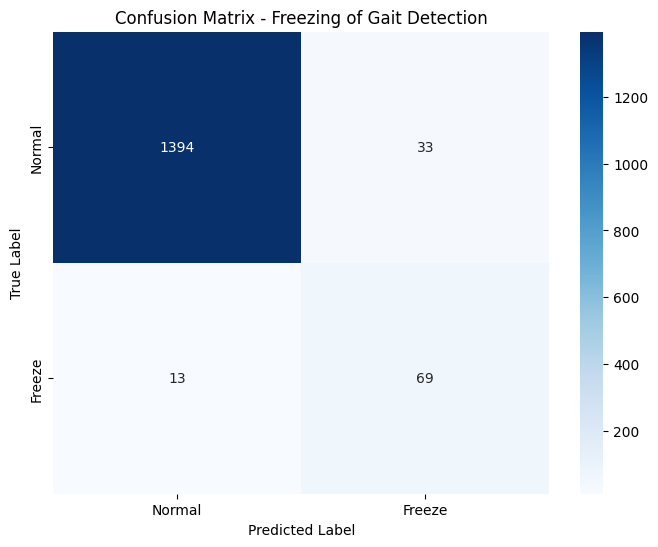

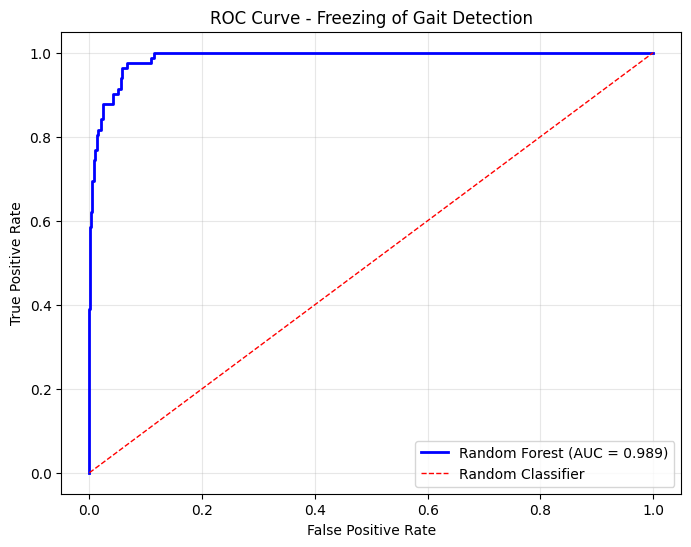


 AUC Score: 0.989


In [ ]:
# ============================================
# STEP 7: TRAIN CLASSIFICATION MODEL
# ============================================

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("\n" + "="*70)
print("STEP 6: TRAINING MODEL")
print("="*70)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train Random Forest
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal Gait', 'Freezing of Gait']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Freeze'],
            yticklabels=['Normal', 'Freeze'])
plt.title('Confusion Matrix - Freezing of Gait Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Freezing of Gait Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"\n AUC Score: {auc_score:.3f}")


STEP 8: FEATURE IMPORTANCE ANALYSIS

 TOP 15 MOST IMPORTANT FEATURES:
--------------------------------------------------
   1. trunk_z_zcr: 0.0621
   2. thigh_x_zcr: 0.0473
   3. trunk_x_mean: 0.0462
   4. trunk_z_mean: 0.0437
   5. thigh_x_freeze_band_power: 0.0430
   6. thigh_x_std: 0.0381
   7. trunk_y_freeze_band_power: 0.0268
   8. ankle_y_max: 0.0260
   9. ankle_y_mean: 0.0257
   10. thigh_x_min: 0.0239
   11. thigh_y_max: 0.0238
   12. trunk_y_max: 0.0232
   13. thigh_x_range: 0.0216
   14. trunk_y_std: 0.0213
   15. thigh_y_rms: 0.0202


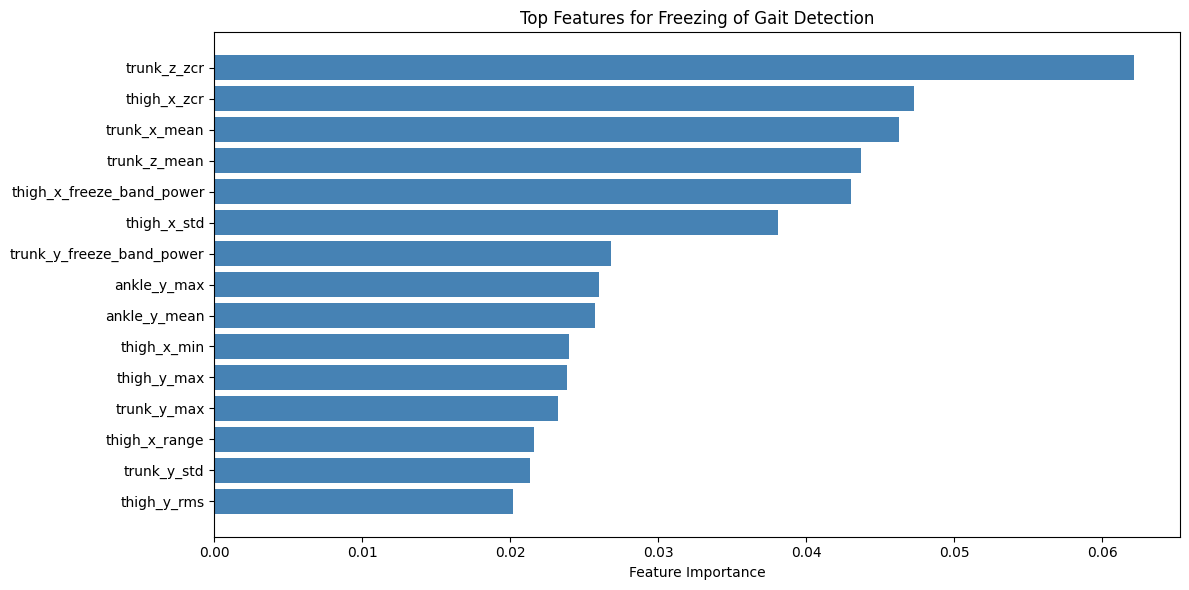

In [ ]:
# ============================================
# STEP 9: FEATURE IMPORTANCE
# ============================================

print("\n" + "="*70)
print("STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

importances = rf_model.feature_importances_
feature_names = feature_df.columns

# Sort by importance
indices = np.argsort(importances)[::-1]
top_n = 15

print(f"\n TOP {top_n} MOST IMPORTANT FEATURES:")
print("-"*50)

for i in range(top_n):
    print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_names[indices[i]] for i in range(top_n-1, -1, -1)])
plt.xlabel('Feature Importance')
plt.title('Top Features for Freezing of Gait Detection')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
# ============================================
# STEP 10: SAVE MODEL, GENERATE REPORT, AND DOWNLOAD FILES
# ============================================

import joblib
from google.colab import files
import os

print("\n" + "="*70)
print("STEP 9: SAVING MODEL AND REPORT")
print("="*70)

# Save model
joblib.dump(rf_model, 'fog_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(" Model saved as 'fog_detection_model.pkl'")

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

# Calculate cross-validation scores if not already defined
try:
    cv_scores_defined = 'cv_scores' in dir()
except:
    cv_scores_defined = False

if not cv_scores_defined:
    print("\n Running cross-validation...")
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
else:
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)

# Generate report
report = f"""
FREEZING OF GAIT DETECTION - FINAL REPORT

DATASET:
- Source: Daphnet Freezing of Gait Dataset
- Files: {len(all_data)}
- Windows: {len(windows)}
- Freeze samples: {np.sum(y)}
- Normal samples: {len(y) - np.sum(y)}

FEATURES:
- Window size: 2.5 seconds
- Features per window: {X.shape[1]}

MODEL:
- Algorithm: Random Forest
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}

PERFORMANCE:
- AUC: {auc_score:.3f}
- Sensitivity: {sensitivity:.3f}
- Specificity: {specificity:.3f}
- Precision: {ppv:.3f}
- Accuracy: {accuracy:.3f}
- CV AUC: {cv_mean:.3f} ± {cv_std:.3f}
"""

print(report)

# Save report
with open('fog_detection_report.txt', 'w') as f:
    f.write(report)
print(" Report saved as 'fog_detection_report.txt'")

print("\n" + "="*70)
print("DOWNLOADING GENERATED FILES")
print("="*70)

# List all files to download
files_to_download = [
    'fog_detection_report.txt',
    'fog_detection_model.pkl',
    'scaler.pkl',
    'confusion_matrix.png',
    'roc_curve.png',
    'feature_importance.png',
    'data_exploration.png'
]

# Download each file
for file_name in files_to_download:
    if os.path.exists(file_name):
        files.download(file_name)
        print(f"Downloaded: {file_name}")
    else:
        print(f"File not found: {file_name}")

print("\n" + "="*70)
print("PROJECT COMPLETE - ALL FILES DOWNLOADED")
print("="*70)
print("\nFiles saved locally:")
print("   - fog_detection_model.pkl")
print("   - scaler.pkl")
print("   - fog_detection_report.txt")
print("   - confusion_matrix.png")
print("   - roc_curve.png")
print("   - feature_importance.png")
print("   - data_exploration.png")


STEP 9: SAVING MODEL AND REPORT
 Model saved as 'fog_detection_model.pkl'

FREEZING OF GAIT DETECTION - FINAL REPORT

DATASET:
- Source: Daphnet Freezing of Gait Dataset
- Files: 2
- Windows: 7542
- Freeze samples: 410
- Normal samples: 7132

FEATURES:
- Window size: 2.5 seconds
- Features per window: 117

MODEL:
- Algorithm: Random Forest
- Training samples: 6033
- Test samples: 1509

PERFORMANCE:
- AUC: 0.989
- Sensitivity: 0.841
- Specificity: 0.977
- Precision: 0.676
- Accuracy: 0.970
- CV AUC: 0.993 ± 0.001

 Report saved as 'fog_detection_report.txt'

DOWNLOADING GENERATED FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fog_detection_report.txt


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: data_exploration.png

PROJECT COMPLETE - ALL FILES DOWNLOADED

Files saved locally:
   - fog_detection_model.pkl
   - scaler.pkl
   - fog_detection_report.txt
   - confusion_matrix.png
   - roc_curve.png
   - feature_importance.png
   - data_exploration.png
